# Imports

In [ ]:
!pip install mlba
!pip install dmba
!pip install mlba lime

import shap
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from mlba import classificationSummary
from lime.lime_tabular import LimeTabularExplainer
from dmba import plotDecisionTree, classificationSummary

# Business Context

**gender**  
Customer gender.  
Values: 0 means male, 1 means female.

**Near_Location**  
Indicates whether the customer lives or works close to the gym. Proximity usually increases convenience and reduces churn risk.

**Partner**  
Shows if the customer works for a partner company that receives discounted membership rates. These customers may have different retention patterns.

**Promo_friends**  
Indicates whether the customer joined through a friend referral. Socially connected customers often have stronger engagement.

**Phone**  
Indicates if the customer provided a phone number. Contactable customers can be reached for retention campaigns.

**Contract_period**  
Length of the membership agreement in months. Longer commitments often signal higher loyalty.

**Group_visits**  
Shows if the customer attends group classes or engages socially during visits. Social involvement is a strong retention indicator.

**Age**  
Customer age in years. Helpful for identifying demographic trends in churn behavior.

**Avg_additional_charges_total**  
Average monthly spending on extras like drinks, personal training, or locker rentals. Higher spending often reflects deeper engagement.

**Month_to_end_contract**  
Remaining months before the membership contract ends. Churn probability often rises near contract expiration.

**Lifetime**  
Total number of months the customer has been a member. Longer membership histories usually correlate with stronger loyalty.

**Avg_class_frequency_total**  
Long term class attendance rate. A strong signal of overall engagement.

**Avg_class_frequency_current_month**  
Class attendance for the current month. Recent dips or changes can be early churn indicators.

**Churn**  
Target variable indicating whether the customer cancelled this month.


# Cleaning and Preprocessing

In [ ]:
gym_df = pd.read_csv("gym_churn_us.csv")
gym_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
gym_df.Churn.value_counts()

,count
Churn,
0,2939
1,1061


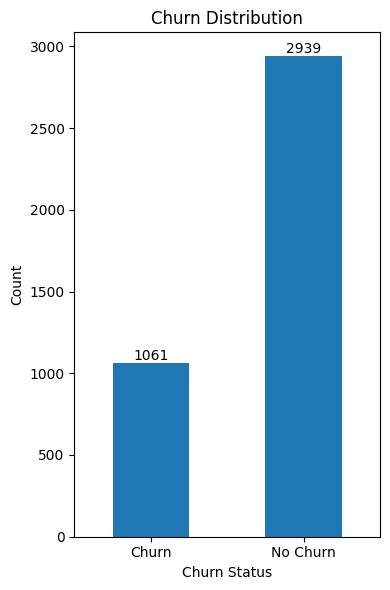

In [ ]:
churn_map = {0: "No Churn", 1: "Churn"}
churn_counts = gym_df["Churn"].map(churn_map).value_counts().sort_index()

plt.figure(figsize=(4, 6))
churn_counts.plot(kind="bar")

for i, v in enumerate(churn_counts):
    plt.text(i, v, str(v), ha="center", va="bottom")


plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.title("Churn Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
gym_df.drop(columns=["Avg_class_frequency_current_month"], inplace=True)
#Current Month is data leaky

In [ ]:
gym_df.Contract_period.value_counts()
gym_df.Contract_period = gym_df.Contract_period.astype('category')

In [ ]:
lifetime_bins = [0, 6, 12, 24, gym_df["Lifetime"].max()]
lifetime_labels = ["0_6_months", "7_12_months", "13_24_months", "25_plus_months"]

gym_df["Lifetime_group"] = pd.cut(
    gym_df["Lifetime"],
    bins=lifetime_bins,
    labels=lifetime_labels,
    right=True,
    include_lowest=True
)

gym_df["Lifetime_group"] = gym_df["Lifetime_group"].astype("category")

In [ ]:
bins = [17, 24, 29, 34, 100]
labels = ["18_24", "25_29", "30_34", "35_plus"]

gym_df["Age_group"] = pd.cut(
    gym_df["Age"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

gym_df["Age_group"] = gym_df["Age_group"].astype('category')

In [ ]:
bins = [0, 3, 6, 9, 12]
labels = ["1_3_months", "4_6_months", "7_9_months", "10_12_months"]

gym_df["Contract_end_group"] = pd.cut(
    gym_df["Month_to_end_contract"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

gym_df["Contract_end_group"] = gym_df["Contract_end_group"].astype("category")

gym_df["Contract_end_group"].value_counts().sort_index()


,count
Contract_end_group,
1_3_months,2244
4_6_months,833
7_9_months,136
10_12_months,787


In [ ]:
import matplotlib.pyplot as plt

# Get ordered counts
contract_counts = gym_df["Contract_end_group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
contract_counts.plot(kind="barh")

for i, v in enumerate(contract_counts):
    plt.text(i, v, str(v), ha="center", va="bottom")


plt.xlabel("Contract_end_group")
plt.ylabel("Count")
plt.title("Contract End Group Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2883675418.py:17: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [ ]:
gym_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   gender                        4000 non-null   int64   
 1   Near_Location                 4000 non-null   int64   
 2   Partner                       4000 non-null   int64   
 3   Promo_friends                 4000 non-null   int64   
 4   Phone                         4000 non-null   int64   
 5   Contract_period               4000 non-null   category
 6   Group_visits                  4000 non-null   int64   
 7   Age                           4000 non-null   int64   
 8   Avg_additional_charges_total  4000 non-null   float64 
 9   Month_to_end_contract         4000 non-null   float64 
 10  Lifetime                      4000 non-null   int64   
 11  Avg_class_frequency_total     4000 non-null   float64 
 12  Churn                         4000 non-null   in

In [ ]:
gym_df = pd.get_dummies(gym_df, columns=["Contract_period", "Age_group", "Contract_end_group", "Lifetime_group"],drop_first=True,dtype = int)
gym_df

,gender,Near_Location,Partner,Promo_friends,Phone,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,...,Contract_period_12,Age_group_25_29,Age_group_30_34,Age_group_35_plus,Contract_end_group_4_6_months,Contract_end_group_7_9_months,Contract_end_group_10_12_months,Lifetime_group_7_12_months,Lifetime_group_13_24_months,Lifetime_group_25_plus_months
0,1,1,1,1,0,1,29,14.227470,5.0,3,...,0,1,0,0,1,0,0,0,0,0
1,0,1,0,0,1,1,31,113.202938,12.0,7,...,1,0,1,0,0,0,1,1,0,0
2,0,1,1,0,1,0,28,129.448479,1.0,2,...,0,1,0,0,0,0,0,0,0,0
3,0,1,1,1,1,1,33,62.669863,12.0,2,...,1,0,1,0,0,0,1,0,0,0
4,1,1,1,1,1,0,26,198.362265,1.0,3,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,0,33,2.406023,12.0,8,...,1,0,1,0,0,0,1,1,0,0
3996,0,1,0,0,1,1,29,68.883764,1.0,1,...,0,1,0,0,0,0,0,0,0,0
3997,1,1,1,1,1,0,28,78.250542,11.0,2,...,1,1,0,0,0,0,1,0,0,0
3998,0,1,1,1,1,0,32,61.912657,5.0,3,...,0,0,1,0,1,0,0,0,0,0


In [ ]:
gym_df.drop(columns=["Age", "Month_to_end_contract", "Lifetime"], inplace=True)

In [ ]:
gym_df.corr()["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
Age_group_25_29,0.196910
gender,0.000708
Phone,-0.001177
Lifetime_group_25_plus_months,-0.021256
Contract_end_group_7_9_months,-0.103348
Lifetime_group_13_24_months,-0.111861
Age_group_35_plus,-0.123128
Near_Location,-0.128098
Partner,-0.157986


# X/Y Split

In [ ]:
x = gym_df.drop(columns=["Churn", "gender"])
y = gym_df["Churn"]

In [ ]:
x_train, x_valid, y_train, y_valid = train_test_split(x, y, test_size=0.3, random_state=42)

# Fit, Evaluate

## Logistic Regression

In [ ]:
logistic = LogisticRegression(random_state = 42)
logistic.fit(x_train, y_train)
classificationSummary(y_true=y_valid, y_pred=logistic.predict(x_valid))

Confusion Matrix (Accuracy 0.8408)

       Prediction
Actual   0   1
     0 813  84
     1 107 196


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
fpr, tpr, _ = roc_curve(y_valid, logistic.predict_proba(x_valid)[:,1])
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(y_valid, logistic.predict_proba(x_valid)[:,1])
pr_auc = average_precision_score(y_valid, logistic.predict_proba(x_valid)[:,1])

## Decision Tree

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth=5,random_state = 42)
decision_tree.fit(x_train, y_train)
classificationSummary(y_true=y_valid, y_pred=decision_tree.predict(x_valid))

Confusion Matrix (Accuracy 0.8258)

       Prediction
Actual   0   1
     0 792 105
     1 104 199


## Random Forest

In [ ]:
random_forest = RandomForestClassifier(n_estimators=100, max_depth=5,random_state = 42)
random_forest.fit(x_train, y_train)
classificationSummary(y_true=y_valid, y_pred=random_forest.predict(x_valid))

Confusion Matrix (Accuracy 0.8408)

       Prediction
Actual   0   1
     0 828  69
     1 122 181


In [ ]:
xgb = XGBClassifier(n_estimators=100, max_depth=5,random_state = 42)
xgb.fit(x_train, y_train)
classificationSummary(y_true=y_valid, y_pred=xgb.predict(x_valid))

Confusion Matrix (Accuracy 0.8158)

       Prediction
Actual   0   1
     0 786 111
     1 110 193


In [ ]:
accuracy_df = pd.DataFrame(columns=["Model", "Accuracy"])

In [ ]:
metrics_data = []

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, random_state=42)
}

for model_name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_valid)
    y_pred_proba = model.predict_proba(x_valid)[:, 1]

    accuracy = accuracy_score(y_valid, y_pred)
    roc_auc = auc(roc_curve(y_valid, y_pred_proba)[0], roc_curve(y_valid, y_pred_proba)[1])
    pr_auc = average_precision_score(y_valid, y_pred_proba)

    metrics_data.append({"Model": model_name, "Accuracy": accuracy, "ROC AUC": roc_auc, "PR AUC": pr_auc})

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,ROC AUC,PR AUC
0,Logistic Regression,0.840833,0.899334,0.744831
1,Decision Tree,0.825833,0.851848,0.592577
2,Random Forest,0.840833,0.883359,0.691615
3,XGBoost,0.815833,0.885795,0.692903


### Logistic Regression is the best model here, with highest accuracy, ROC AUC and PR scores

# Visualizations

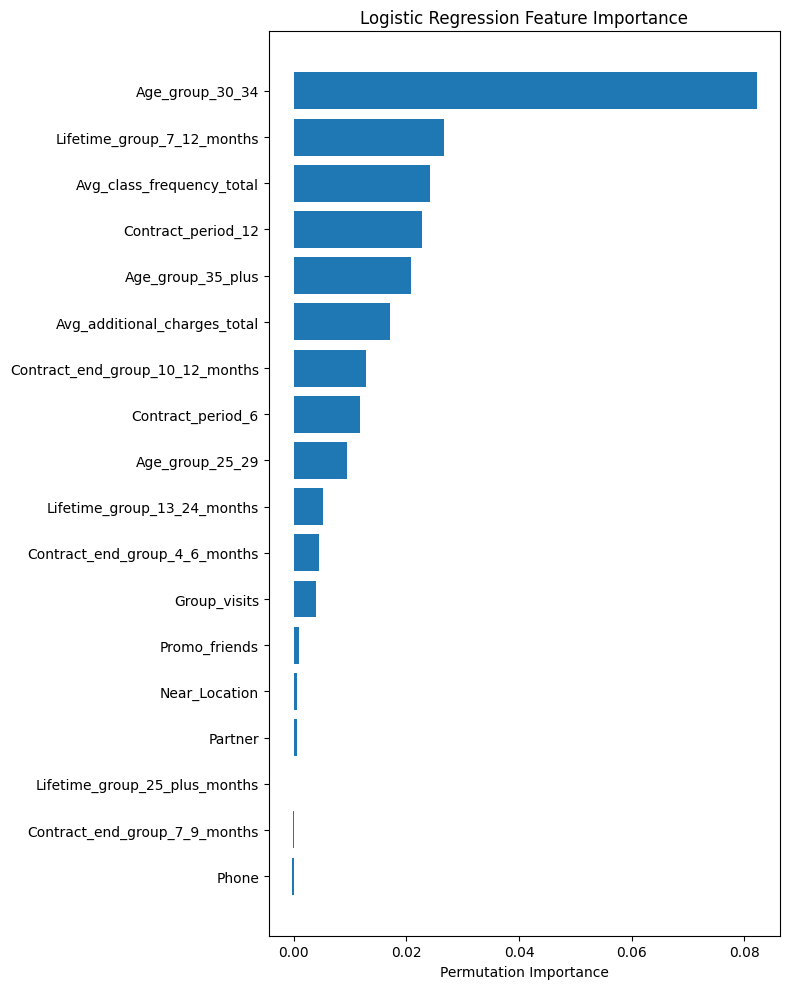

In [ ]:
perm = permutation_importance(logistic, x_valid, y_valid, n_repeats=15, random_state=42)
perm_df = pd.DataFrame({'Features': x.columns, 'Importance': perm.importances_mean})
perm_df = perm_df.sort_values('Importance')

plt.figure(figsize=(8, 10))
plt.barh(perm_df['Features'], perm_df['Importance'])
plt.xlabel("Permutation Importance")
plt.title("Logistic Regression Feature Importance")
plt.tight_layout()
plt.show()

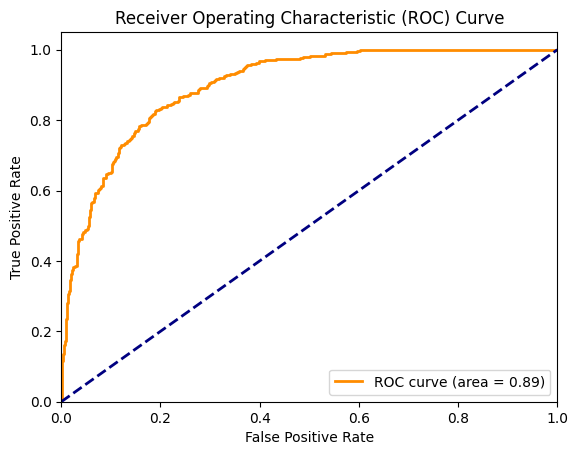

In [ ]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

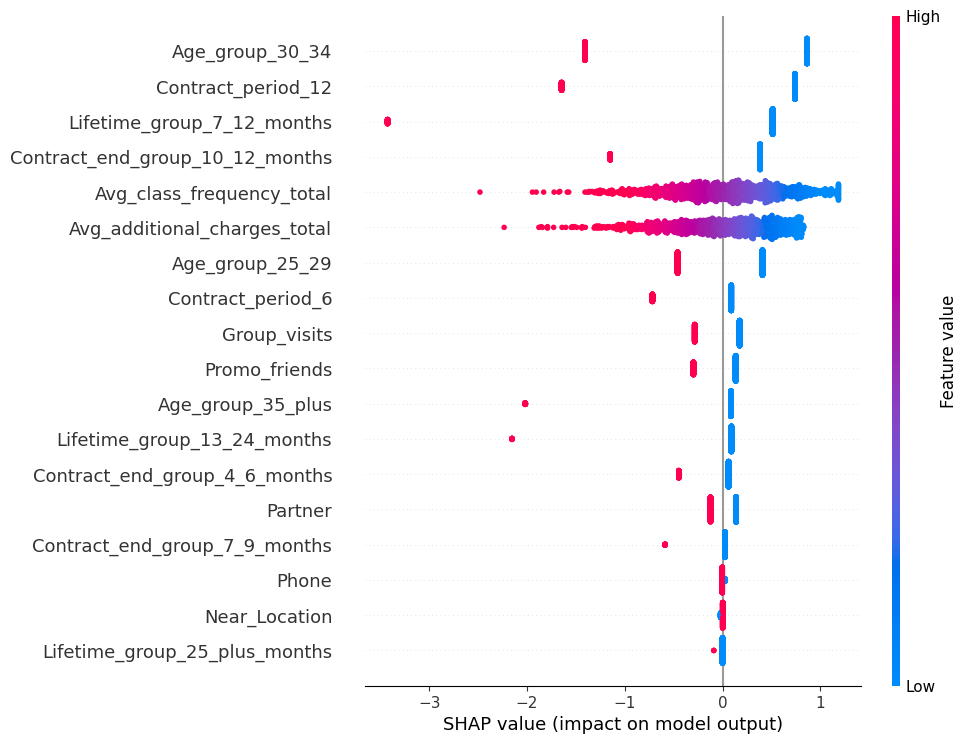

In [ ]:
explainer = shap.Explainer(logistic, x_train)

shap_values = explainer(x_valid)

shap.plots.beeswarm(shap_values, max_display=20)

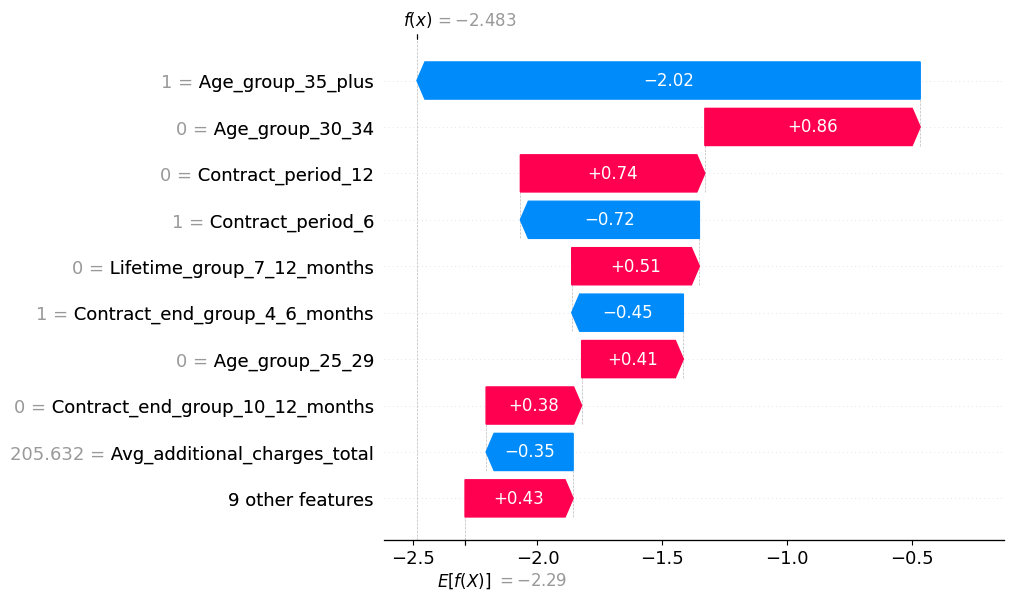

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
# LIME explainer for logistic regression
explainer = LimeTabularExplainer(
    training_data=x_train.values,
    feature_names=x_train.columns.tolist(),
    class_names=["0", "1"],   # or ["Stayed", "Churned"] if you prefer
    mode="classification"
)

# Pick an instance from the validation set to explain
instance_idx = 0
instance = x_valid.iloc[instance_idx].values

# Explain the prediction for this instance using logistic.predict_proba
explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=logistic.predict_proba,
    num_features=len(x_valid.columns)
)

# Visualize in notebook
explanation.show_in_notebook(show_table=True, show_all=False)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
